# RGB-Grains — Exploratory Data Analysis

Interactive EDA over the per-grain hyperspectral crops in `data/`. Each `.npz`
holds `x` (252×252×3 `int16`, spectral bands **[22, 53, 89]**) on a black
background, plus a `means_over_spectralon` reference.

This notebook reuses the parsing / statistics helpers in
[`src/eda.py`](src/eda.py) (single source of truth, kept in sync with
`src/dataset.py`) and renders every figure **inline**. To regenerate all figures
as PNGs + a Markdown report on disk instead, run:

```bash
python src/eda.py --out eda_outputs --max-per-class 400
```

**Contents**
1. Setup & load metadata
2. Inventory & class balance
3. Split-relevant structure (microplots)
4. Acquisition: illumination & timeline
5. Grain morphology (active-pixel area)
6. Radiometry (spectral signatures & reflectance scatter)
7. Mixtures
8. Spectralon reference
9. Example grains (montages)
10. Findings

## 1. Setup & load metadata

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, "src")          # so `import eda` works from the repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import eda   # parsing + image-stats helpers live here

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
PALETTE = sns.color_palette("colorblind", 12)

# Resolve paths relative to the repo root even if the kernel starts elsewhere.
ROOT = os.getcwd()
DATA_DIR = "data"
MIX_CSV  = "perfomix_mixtures.csv"
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 1.26.4 | pandas 2.3.3


In [2]:
mix_dict = eda._load_mix_dict(MIX_CSV)
df = eda.build_metadata(DATA_DIR, mix_dict)
print(f"{len(df):,} grain crops across {df['dataset'].nunique()} folders")
df.head()

32,768 grain crops across 4 folders


,path,filename,dataset,kind,label,label_name,n_components,microplot,replicate,year,illumination,datetime
0,data/SCOOP-R2022-bacs_processed/grain0_R22-sco...,grain0_R22-scoop-bac17-1_8000_us_2x_2022-08-26...,SCOOP-R2022-bacs_processed,bac,bac17,EL4X-35,1,bac17,1.0,2022,8000,2022-08-26 07:53:32
1,data/SCOOP-R2022-bacs_processed/grain0_R22-sco...,grain0_R22-scoop-bac17-2_8000_us_2x_2022-08-26...,SCOOP-R2022-bacs_processed,bac,bac17,EL4X-35,1,bac17,2.0,2022,8000,2022-08-26 07:57:57
2,data/SCOOP-R2022-bacs_processed/grain0_R22-sco...,grain0_R22-scoop-bac17-3_8000_us_2x_2022-08-26...,SCOOP-R2022-bacs_processed,bac,bac17,EL4X-35,1,bac17,3.0,2022,8000,2022-08-26 08:02:40
3,data/SCOOP-R2022-bacs_processed/grain0_R22-sco...,grain0_R22-scoop-bac17-4_8000_us_2x_2022-08-26...,SCOOP-R2022-bacs_processed,bac,bac17,EL4X-35,1,bac17,4.0,2022,8000,2022-08-26 08:07:31
4,data/SCOOP-R2022-bacs_processed/grain0_R22-sco...,grain0_R22-scoop-bac18-1_8000_us_2x_2022-08-25...,SCOOP-R2022-bacs_processed,bac,bac18,EL4X-199,1,bac18,1.0,2022,8000,2022-08-25 10:10:52


`df` is one row per grain, parsed **purely from filenames** (no image load), with:
`dataset · kind · label · label_name · n_components · microplot · replicate · year · illumination · datetime`.
`kind` ∈ {`pure`, `mix`, `bac`}.

In [3]:
df[["kind", "label", "label_name", "microplot", "year", "illumination"]].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
kind,32768,3,pure,14105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,32768,71,var5,2345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label_name,32768,46,GQ4X-83,3442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
microplot,32768,130,bac57,1521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,32768.0,NaN,NaN,NaN,2021.197876,0.700068,2020.0,2021.0,2021.0,2022.0,2022.0
illumination,32768.0,NaN,NaN,NaN,7625.213623,606.025847,7000.0,7000.0,8000.0,8000.0,11000.0


## 2. Inventory & class balance

,dataset,kind,grains
0,SCOOP-R2022-bacs_processed,bac,11913
1,perfomix_2019-2020_IE_HSI_mix_processed,mix,6750
2,perfomix_2020-2021_IE_HSI_var1-8_processed,pure,13370
3,withdraw_var5_2020_x39y20-var5,pure,735


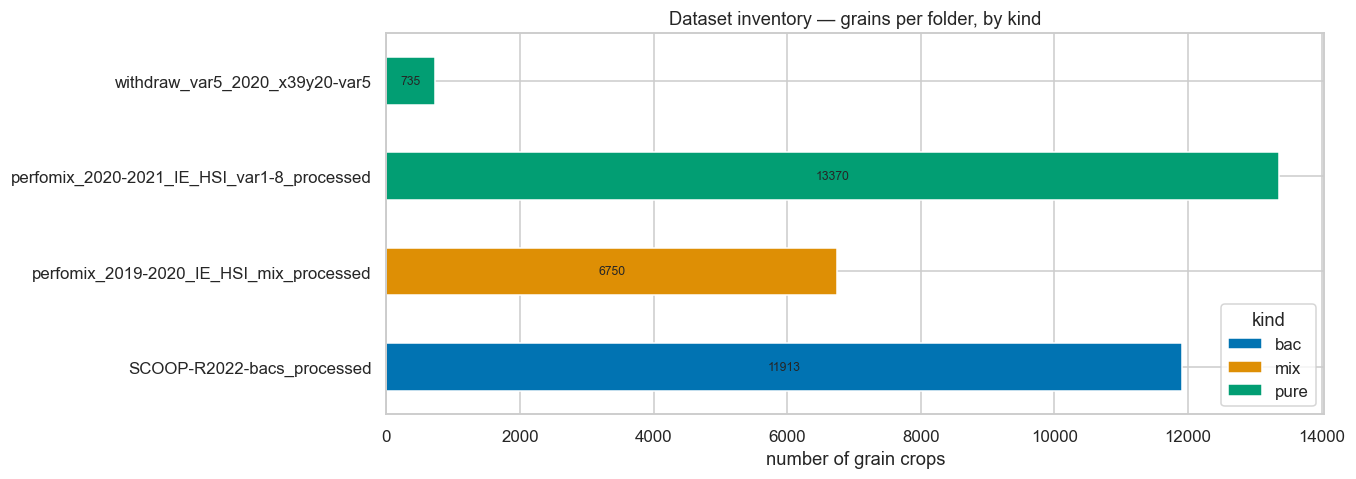

In [4]:
inv = df.groupby(["dataset", "kind"]).size().rename("grains").reset_index()
display(inv)

counts = df.groupby(["dataset", "kind"]).size().unstack(fill_value=0)
ax = counts.plot(kind="barh", stacked=True, figsize=(11, 4.5), color=PALETTE)
ax.set_xlabel("number of grain crops"); ax.set_ylabel("")
ax.set_title("Dataset inventory — grains per folder, by kind")
for c in ax.containers:
    ax.bar_label(c, label_type="center", fmt=lambda v: f"{int(v)}" if v else "", fontsize=8)
ax.legend(title="kind", loc="lower right"); plt.show()

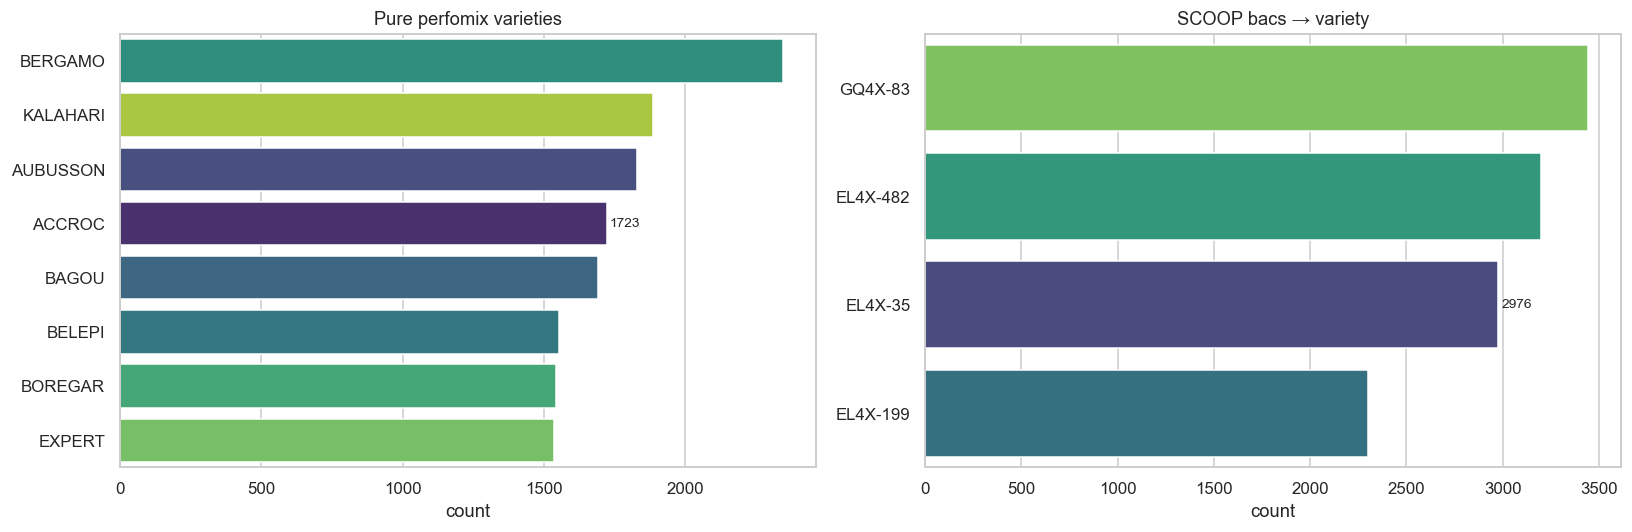

pure:  8 classes, 14,105 grains, imbalance 1.53x (max/min)
 bac:  4 classes, 11,913 grains, imbalance 1.50x (max/min)
 mix: 34 classes,  6,750 grains, imbalance 14.14x (max/min)


In [5]:
# Class balance for the pure-label kinds (mixtures analysed separately in §7).
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (k, title) in zip(axes, [("pure", "Pure perfomix varieties"),
                                  ("bac", "SCOOP bacs → variety")]):
    sub = df[df["kind"] == k]
    order = sub["label_name"].value_counts().index
    sns.countplot(data=sub, y="label_name", order=order, ax=ax,
                  hue="label_name", palette="viridis", legend=False)
    ax.set_title(title); ax.set_xlabel("count"); ax.set_ylabel("")
    ax.bar_label(ax.containers[0], fontsize=9, padding=2)
plt.tight_layout(); plt.show()

for kind in ["pure", "bac", "mix"]:
    sub = df[df["kind"] == kind]
    vc = sub["label_name"].value_counts()
    print(f"{kind:>4}: {sub['label_name'].nunique():>2} classes, {len(sub):>6,} grains, "
          f"imbalance {vc.max()/max(vc.min(),1):.2f}x (max/min)")

## 3. Split-relevant structure (microplots)

`src/dataset.py` splits **by microplot**, so each column below is an indivisible
train/test unit — this bounds how many cross-validation folds are achievable and
exposes any class that lacks enough microplots.

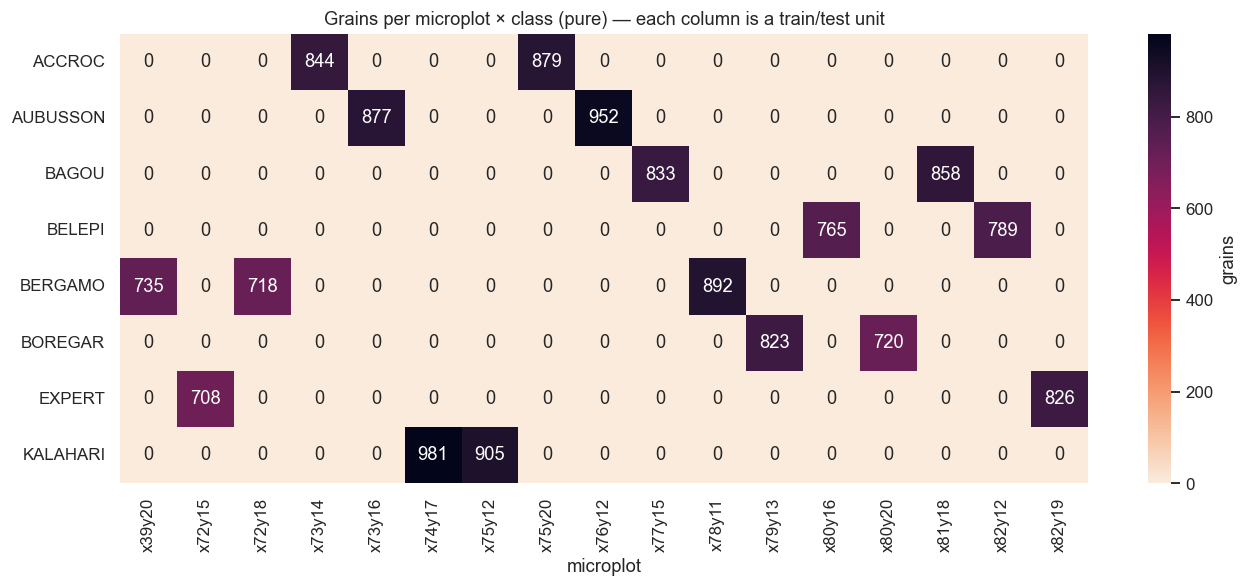

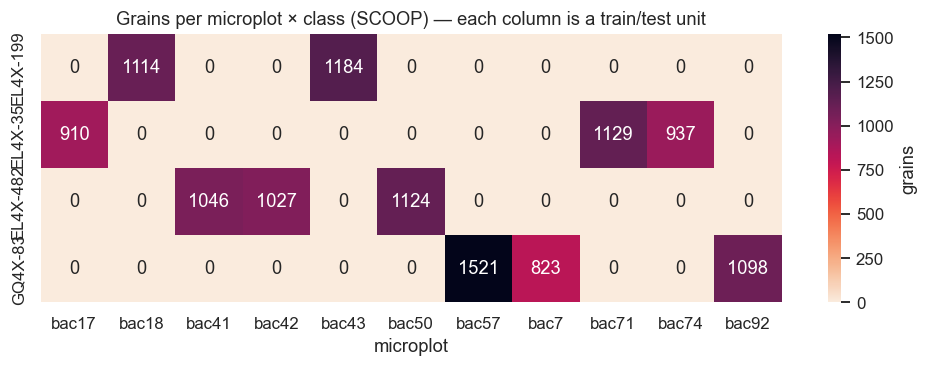

In [6]:
for kind, tag in [("pure", "pure"), ("bac", "SCOOP")]:
    sub = df[(df["kind"] == kind) & df["microplot"].notna()]
    if sub.empty:
        continue
    pivot = sub.pivot_table(index="label_name", columns="microplot",
                            values="path", aggfunc="count", fill_value=0)
    fig, ax = plt.subplots(figsize=(max(8, 0.55*pivot.shape[1]+3),
                                    max(3.5, 0.5*pivot.shape[0]+1.5)))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="rocket_r", ax=ax,
                cbar_kws={"label": "grains"})
    ax.set_title(f"Grains per microplot × class ({tag}) — each column is a train/test unit")
    ax.set_xlabel("microplot"); ax.set_ylabel("")
    plt.tight_layout(); plt.show()

Note two structural quirks the split code must handle:

* **BERGAMO** carries a *third* pure microplot `x39y20` (folder
  `withdraw_var5_2020_x39y20-var5`) — the "cursed microplot" special-cased as
  `c != 4` in `load_datasets_microplot_split`.
* **SCOOP** matches Martin's README table (3 bacs per variety) **except `bac14`**
  (listed for EL4X-199) which is absent from disk.

## 4. Acquisition — illumination & timeline

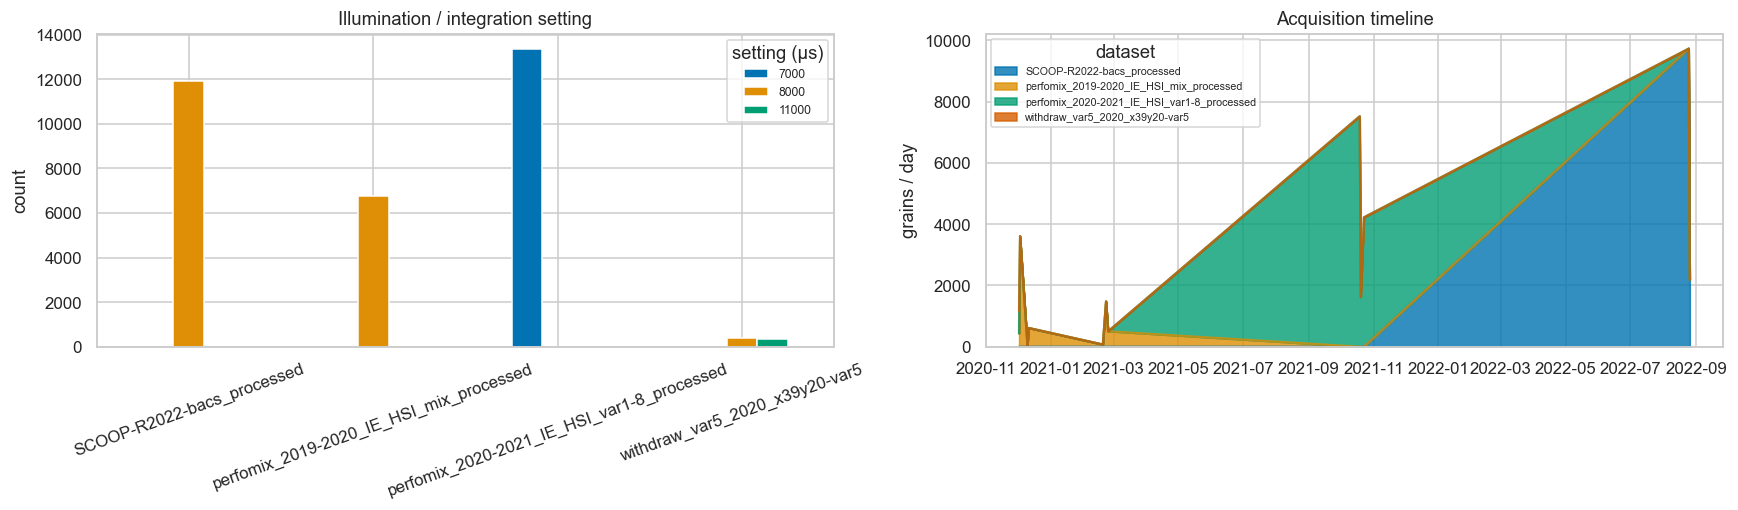

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
ct = df.dropna(subset=["illumination"]).groupby(["dataset", "illumination"]).size().unstack(fill_value=0)
ct.plot(kind="bar", ax=axes[0], color=PALETTE)
axes[0].set_title("Illumination / integration setting"); axes[0].set_ylabel("count")
axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="setting (µs)", fontsize=8)

tl = df.dropna(subset=["datetime"]).copy()
tl["date"] = tl["datetime"].dt.date
tl.groupby(["date", "dataset"]).size().unstack(fill_value=0).plot(
    kind="area", stacked=True, ax=axes[1], alpha=0.8, color=PALETTE)
axes[1].set_title("Acquisition timeline"); axes[1].set_ylabel("grains / day")
axes[1].set_xlabel(""); axes[1].legend(title="dataset", fontsize=7)
plt.tight_layout(); plt.show()

## 5. Grain morphology — active-pixel area

The next sections need pixel data, so we stream a **balanced sample** of up to
`MAX_PER_CLASS` grains per (dataset, label) and compute area, fill fraction,
per-band foreground reflectance and the spectralon reference. Increase
`MAX_PER_CLASS` for smoother distributions (slower).

In [8]:
MAX_PER_CLASS = 250   # grains sampled per class for pixel-level stats
stats = eda.sample_image_stats(df, max_per_class=MAX_PER_CLASS, seed=42)
print(f"measured {len(stats):,} grains")
stats[["area", "fill_frac", "refl0", "refl1", "refl2", "brightness"]].describe().T

measured 11,205 grains


,count,mean,std,min,25%,50%,75%,max
area,11205.0,8469.087639,1863.553550,0.0,7346.000000,8469.000000,9540.000000,19880.000000
fill_frac,11205.0,0.133363,0.029345,0.0,0.115678,0.133362,0.150227,0.313051
refl0,11205.0,0.200959,0.045900,0.0,0.169843,0.198114,0.228346,0.953135
refl1,11205.0,0.325456,0.068295,0.0,0.276892,0.322038,0.372974,1.034879
refl2,11205.0,0.371402,0.077396,0.0,0.315386,0.364837,0.429119,0.906463
brightness,11205.0,0.299272,0.061912,0.0,0.255754,0.296560,0.342699,0.964826


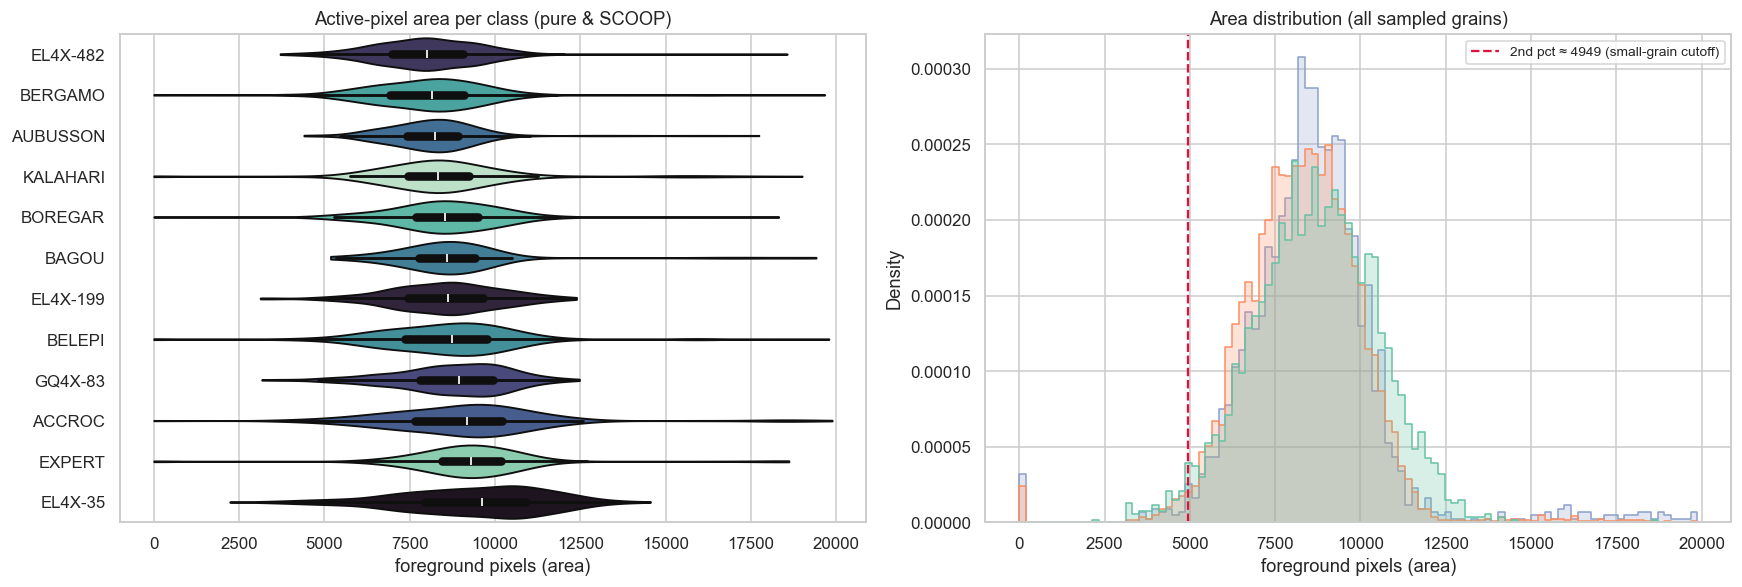

225 sampled grains below the 2nd-percentile area → dust / half-grain candidates for README §5.5 cleaning


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
pc = stats[stats["kind"].isin(["pure", "bac"])]
order = pc.groupby("label_name")["area"].median().sort_values().index
sns.violinplot(data=pc, x="area", y="label_name", order=order, ax=axes[0],
               density_norm="width", cut=0, hue="label_name", legend=False, palette="mako")
axes[0].set_title("Active-pixel area per class (pure & SCOOP)")
axes[0].set_xlabel("foreground pixels (area)"); axes[0].set_ylabel("")

sns.histplot(data=stats, x="area", hue="kind", element="step", stat="density",
             common_norm=False, ax=axes[1], palette="Set2")
cut = stats["area"].quantile(0.02)
axes[1].axvline(cut, color="crimson", ls="--", label=f"2nd pct ≈ {int(cut)} (small-grain cutoff)")
axes[1].set_title("Area distribution (all sampled grains)")
axes[1].set_xlabel("foreground pixels (area)"); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

n_tiny = int((stats["area"] < cut).sum())
print(f"{n_tiny} sampled grains below the 2nd-percentile area → dust / half-grain "
      f"candidates for README §5.5 cleaning")

## 6. Radiometry — spectral signatures & reflectance scatter

Per-band mean reflectance over foreground pixels (`x / CH_SCALE`) is the raw
signal the classifier keys on. Below: how separable the classes are by their
band statistics alone.

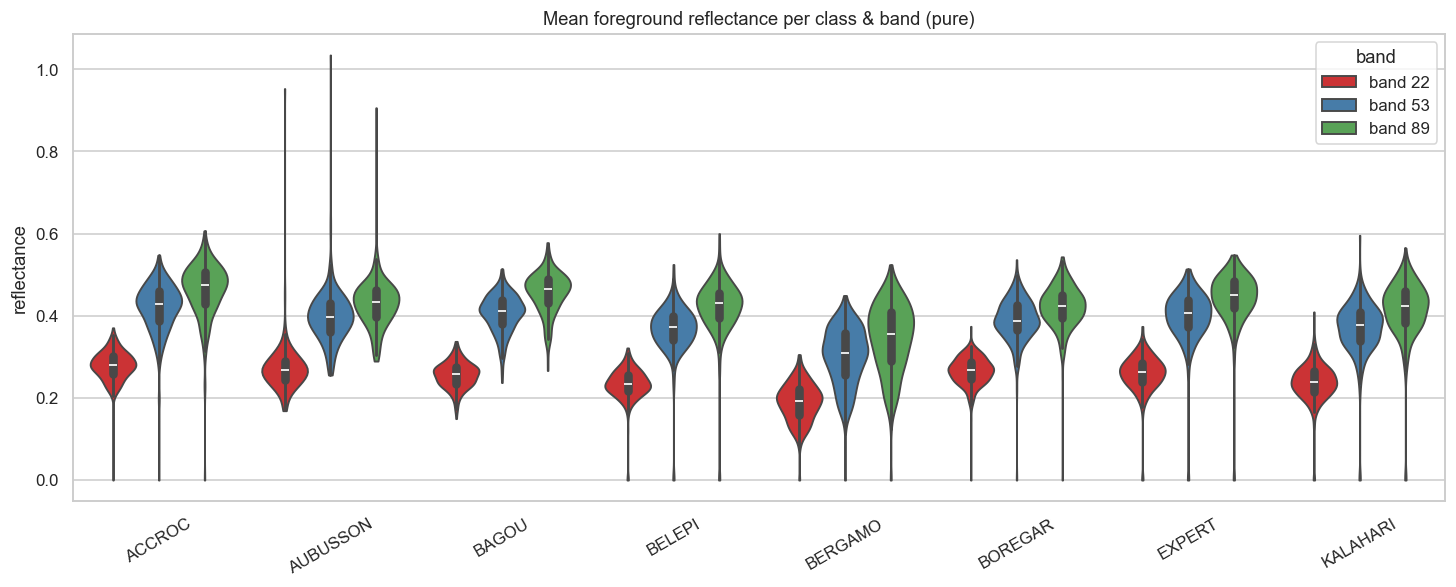

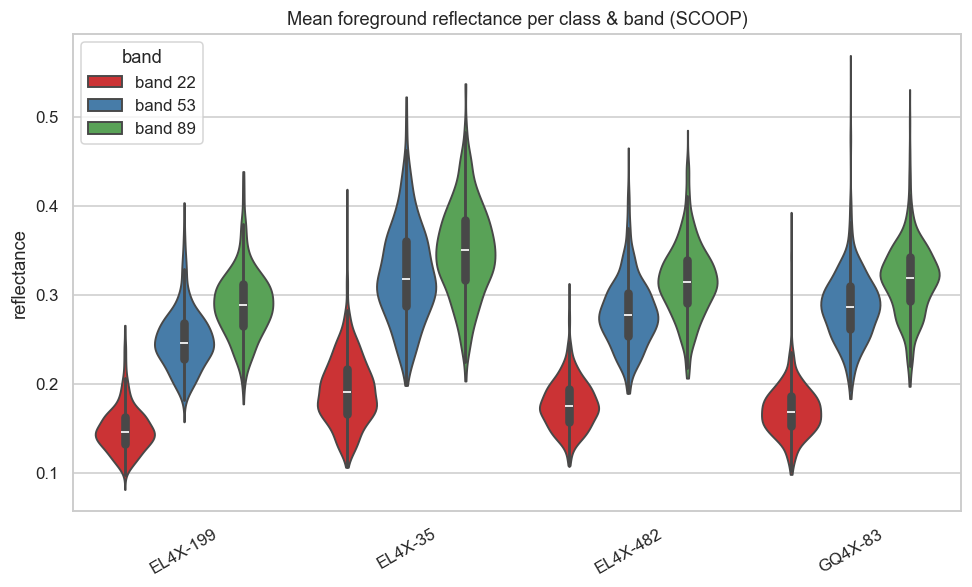

In [10]:
CH_LABELS = eda.CH_LABELS
for kind, tag in [("pure", "pure"), ("bac", "SCOOP")]:
    sub = stats[stats["kind"] == kind]
    if sub.empty:
        continue
    long = sub.melt(id_vars=["label_name"], value_vars=["refl0", "refl1", "refl2"],
                    var_name="band", value_name="reflectance")
    long["band"] = long["band"].map(dict(zip(["refl0","refl1","refl2"], CH_LABELS)))
    order = sorted(sub["label_name"].unique())
    fig, ax = plt.subplots(figsize=(max(9, 1.3*len(order)+3), 5.5))
    sns.violinplot(data=long, x="label_name", y="reflectance", hue="band", order=order,
                   ax=ax, density_norm="width", cut=0, palette="Set1")
    ax.set_title(f"Mean foreground reflectance per class & band ({tag})")
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30); ax.legend(title="band")
    plt.tight_layout(); plt.show()

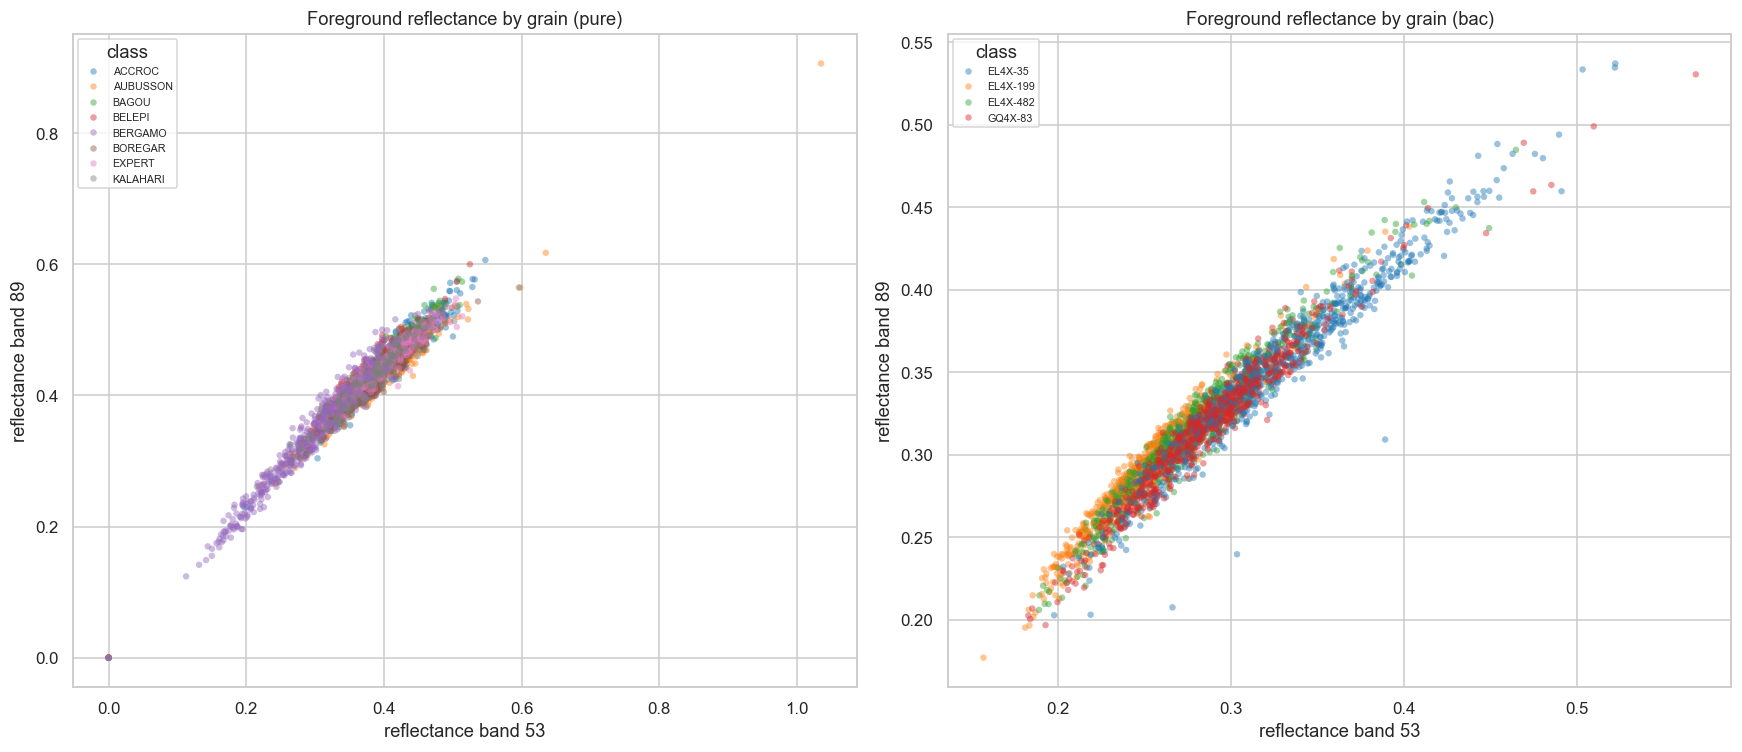

In [11]:
# Per-grain reflectance scatter (band53 vs band89), coloured by class.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, kind in zip(axes, ["pure", "bac"]):
    sub = stats[stats["kind"] == kind]
    sns.scatterplot(data=sub, x="refl1", y="refl2", hue="label_name",
                    alpha=0.45, s=18, ax=ax, palette="tab10", edgecolor="none")
    ax.set_xlabel(f"reflectance {CH_LABELS[1]}"); ax.set_ylabel(f"reflectance {CH_LABELS[2]}")
    ax.set_title(f"Foreground reflectance by grain ({kind})")
    ax.legend(title="class", fontsize=7)
plt.tight_layout(); plt.show()

## 7. Mixtures

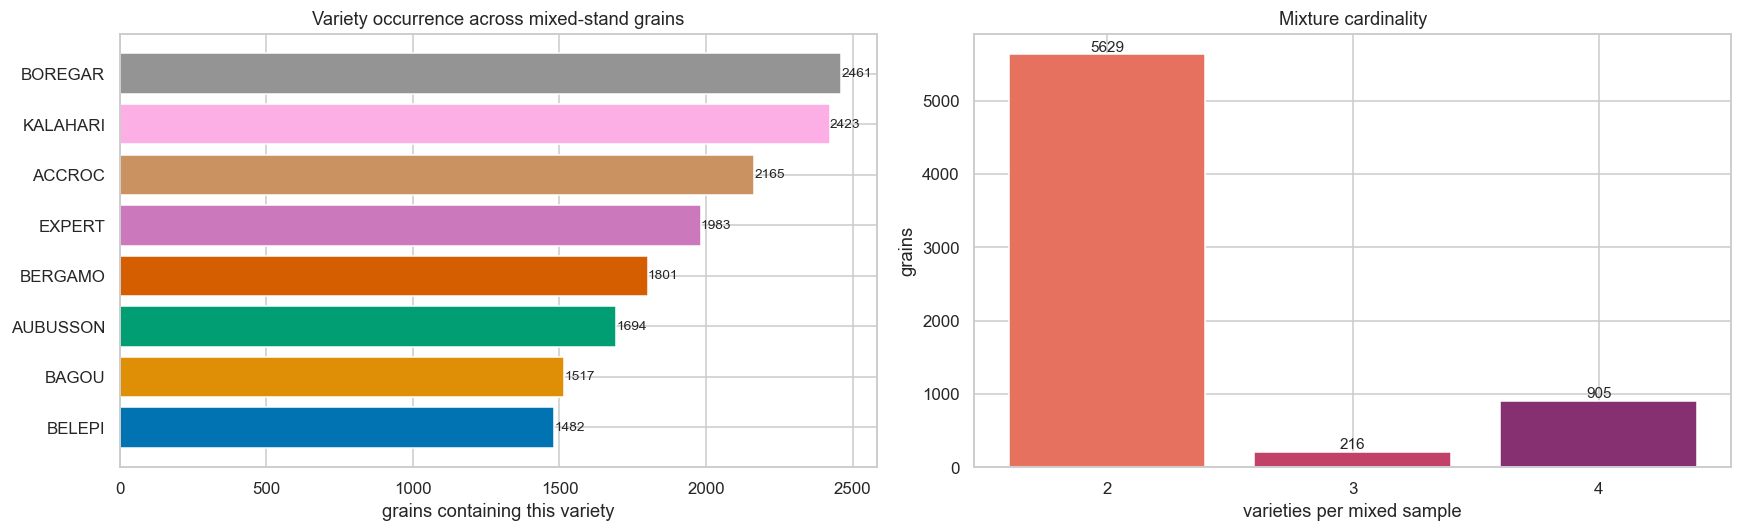

In [12]:
sub = df[df["kind"] == "mix"]
var_counter = Counter()
for _, r in sub.iterrows():
    for v in (mix_dict.get(r["label"]) or []):
        var_counter[v] += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
vs = pd.Series(var_counter).sort_values()
axes[0].barh(vs.index, vs.values, color=PALETTE)
axes[0].bar_label(axes[0].containers[0], fontsize=9)
axes[0].set_title("Variety occurrence across mixed-stand grains")
axes[0].set_xlabel("grains containing this variety")

card = sub["n_components"].value_counts().sort_index()
axes[1].bar(card.index.astype(str), card.values, color=sns.color_palette("flare", len(card)))
axes[1].bar_label(axes[1].containers[0], fontsize=10)
axes[1].set_title("Mixture cardinality"); axes[1].set_xlabel("varieties per mixed sample")
axes[1].set_ylabel("grains")
plt.tight_layout(); plt.show()

## 8. Spectralon reference

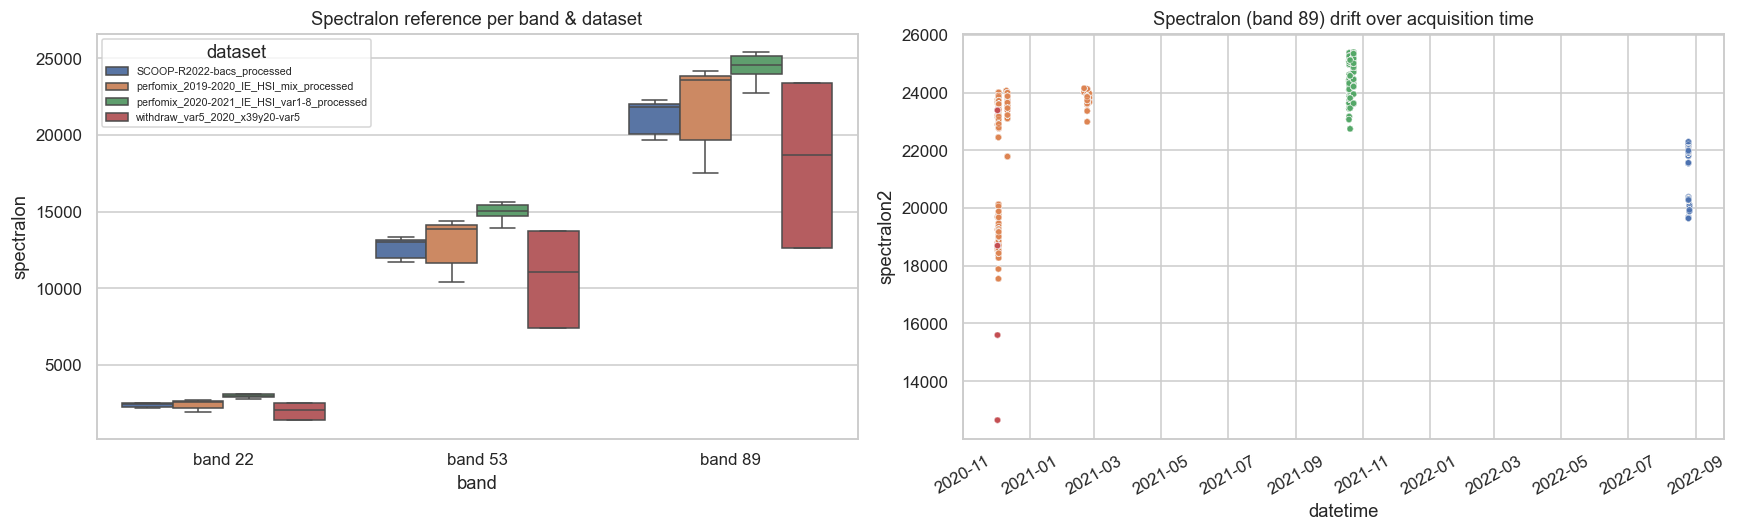

In [13]:
sub = stats.dropna(subset=["spectralon2"]).copy()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
long = sub.melt(id_vars=["dataset"], value_vars=["spectralon0","spectralon1","spectralon2"],
                var_name="band", value_name="spectralon")
long["band"] = long["band"].map(dict(zip(["spectralon0","spectralon1","spectralon2"], CH_LABELS)))
sns.boxplot(data=long, x="band", y="spectralon", hue="dataset", ax=axes[0])
axes[0].set_title("Spectralon reference per band & dataset"); axes[0].legend(fontsize=7, title="dataset")

sub2 = sub.dropna(subset=["datetime"])
sns.scatterplot(data=sub2, x="datetime", y="spectralon2", hue="dataset",
                alpha=0.5, s=16, ax=axes[1], legend=False)
axes[1].set_title(f"Spectralon ({CH_LABELS[2]}) drift over acquisition time")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## 9. Example grains

Rendered exactly as the model sees them (`x / CH_SCALE`, clipped to [0, 1],
centre-cropped to 176 px).

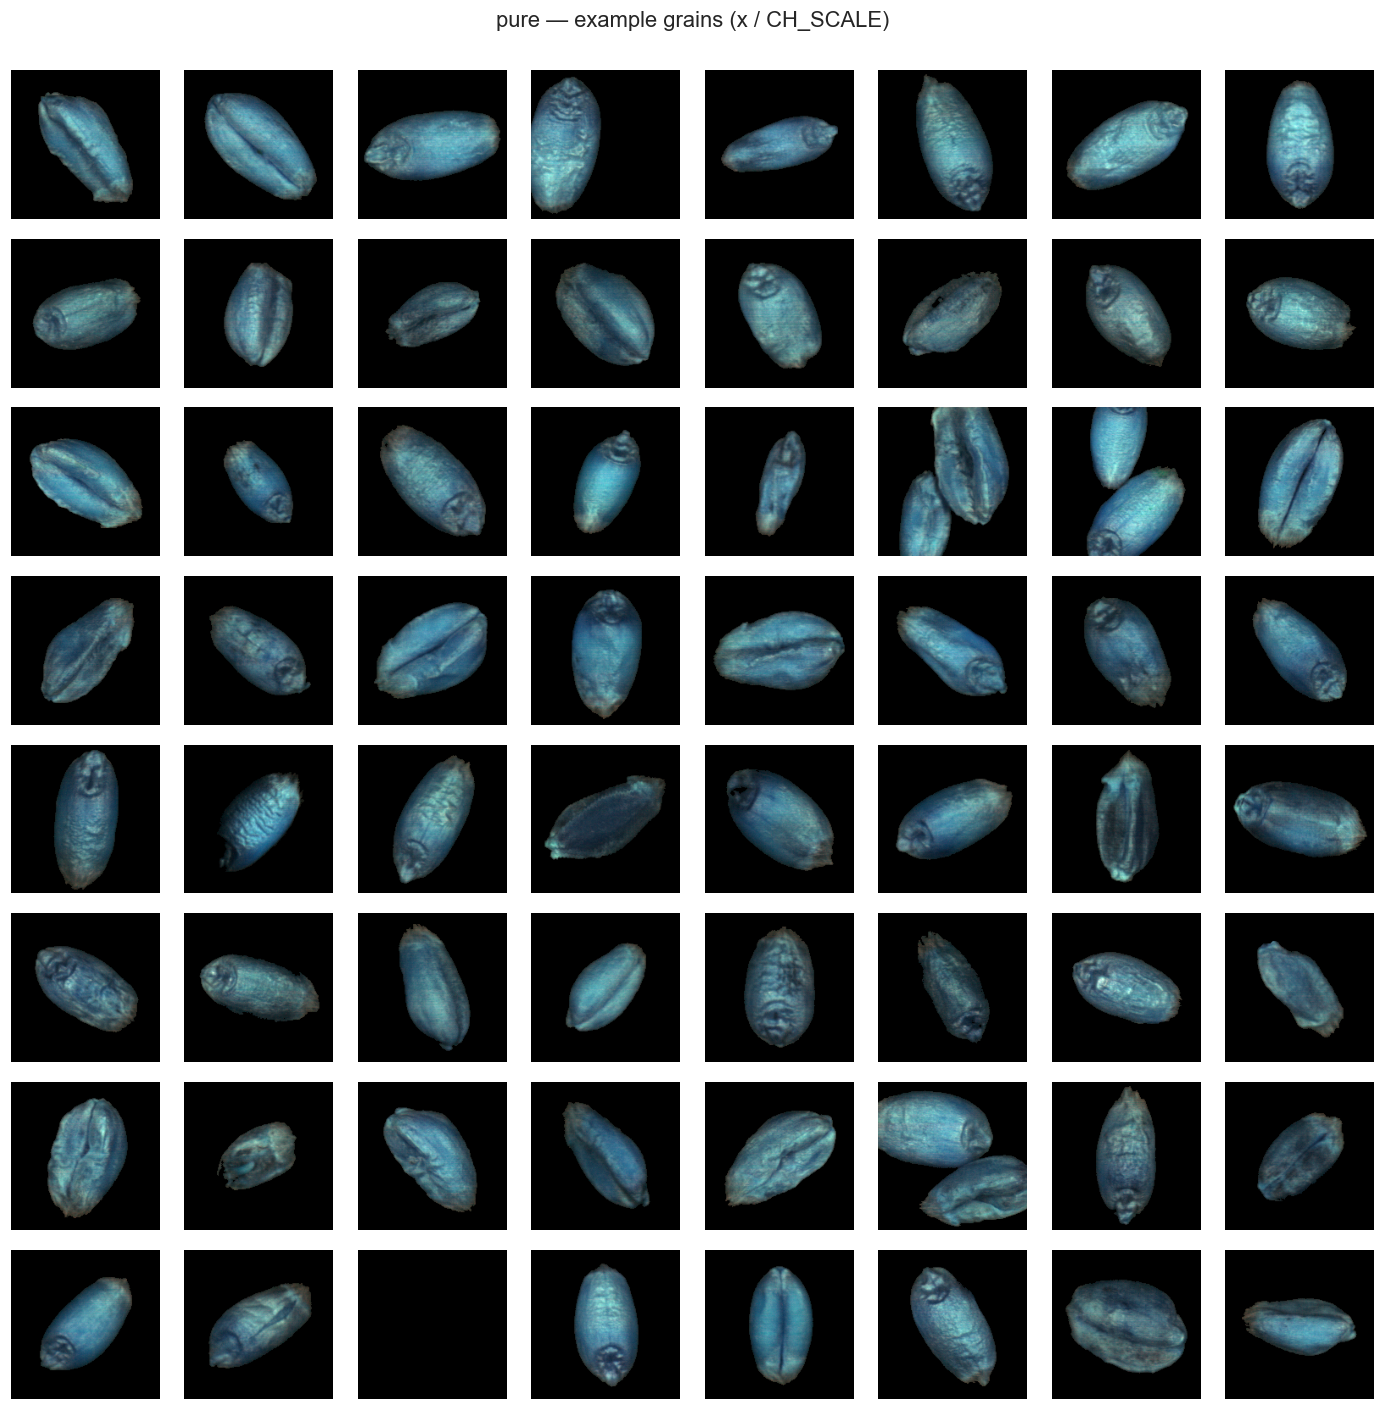

In [14]:
def montage(kind, n_per=8, max_rows=10, seed=42):
    sub = df[df["kind"] == kind]
    rng = np.random.default_rng(seed)
    classes = sorted(sub["label_name"].dropna().unique())
    if len(classes) > max_rows:            # too many classes → flat random grid
        pick = rng.choice(sub["path"].to_numpy(), min(max_rows*n_per, len(sub)), replace=False)
        nrow = int(np.ceil(len(pick)/n_per))
        fig, axes = plt.subplots(nrow, n_per, figsize=(1.6*n_per, 1.6*nrow), squeeze=False)
        for i, ax in enumerate(axes.flat):
            ax.axis("off")
            if i < len(pick):
                img = eda.render_rgb(pick[i])
                if img is not None: ax.imshow(img)
        fig.suptitle(f"{kind} — {len(classes)} classes, random sample", y=1.0)
    else:
        fig, axes = plt.subplots(len(classes), n_per, figsize=(1.6*n_per, 1.6*len(classes)), squeeze=False)
        for r, cls in enumerate(classes):
            paths = sub[sub["label_name"] == cls]["path"].to_numpy()
            sel = rng.choice(paths, min(n_per, len(paths)), replace=False)
            for c in range(n_per):
                ax = axes[r][c]; ax.axis("off")
                if c < len(sel):
                    img = eda.render_rgb(sel[c])
                    if img is not None: ax.imshow(img)
                if c == 0:
                    ax.set_ylabel(cls, rotation=0, ha="right", va="center", fontsize=9)
        fig.suptitle(f"{kind} — example grains (x / CH_SCALE)", y=1.0)
    plt.tight_layout(); plt.show()

montage("pure")

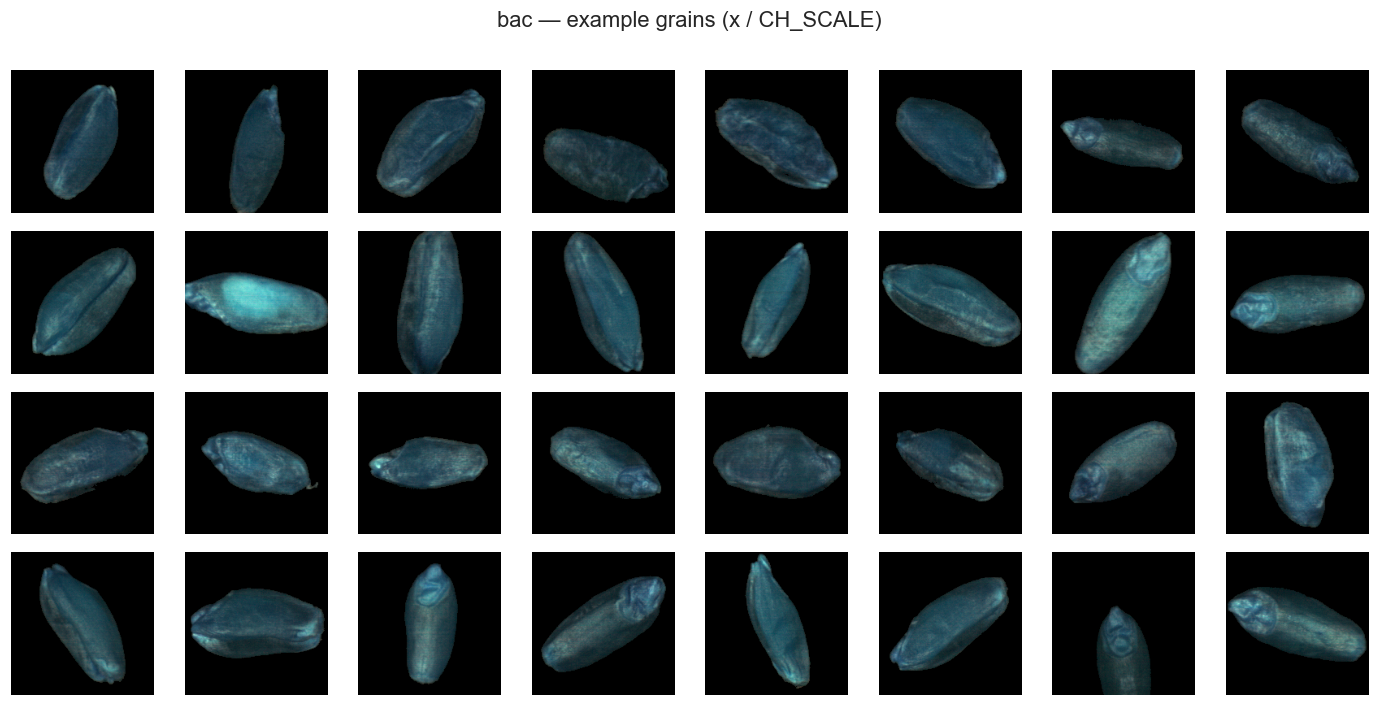

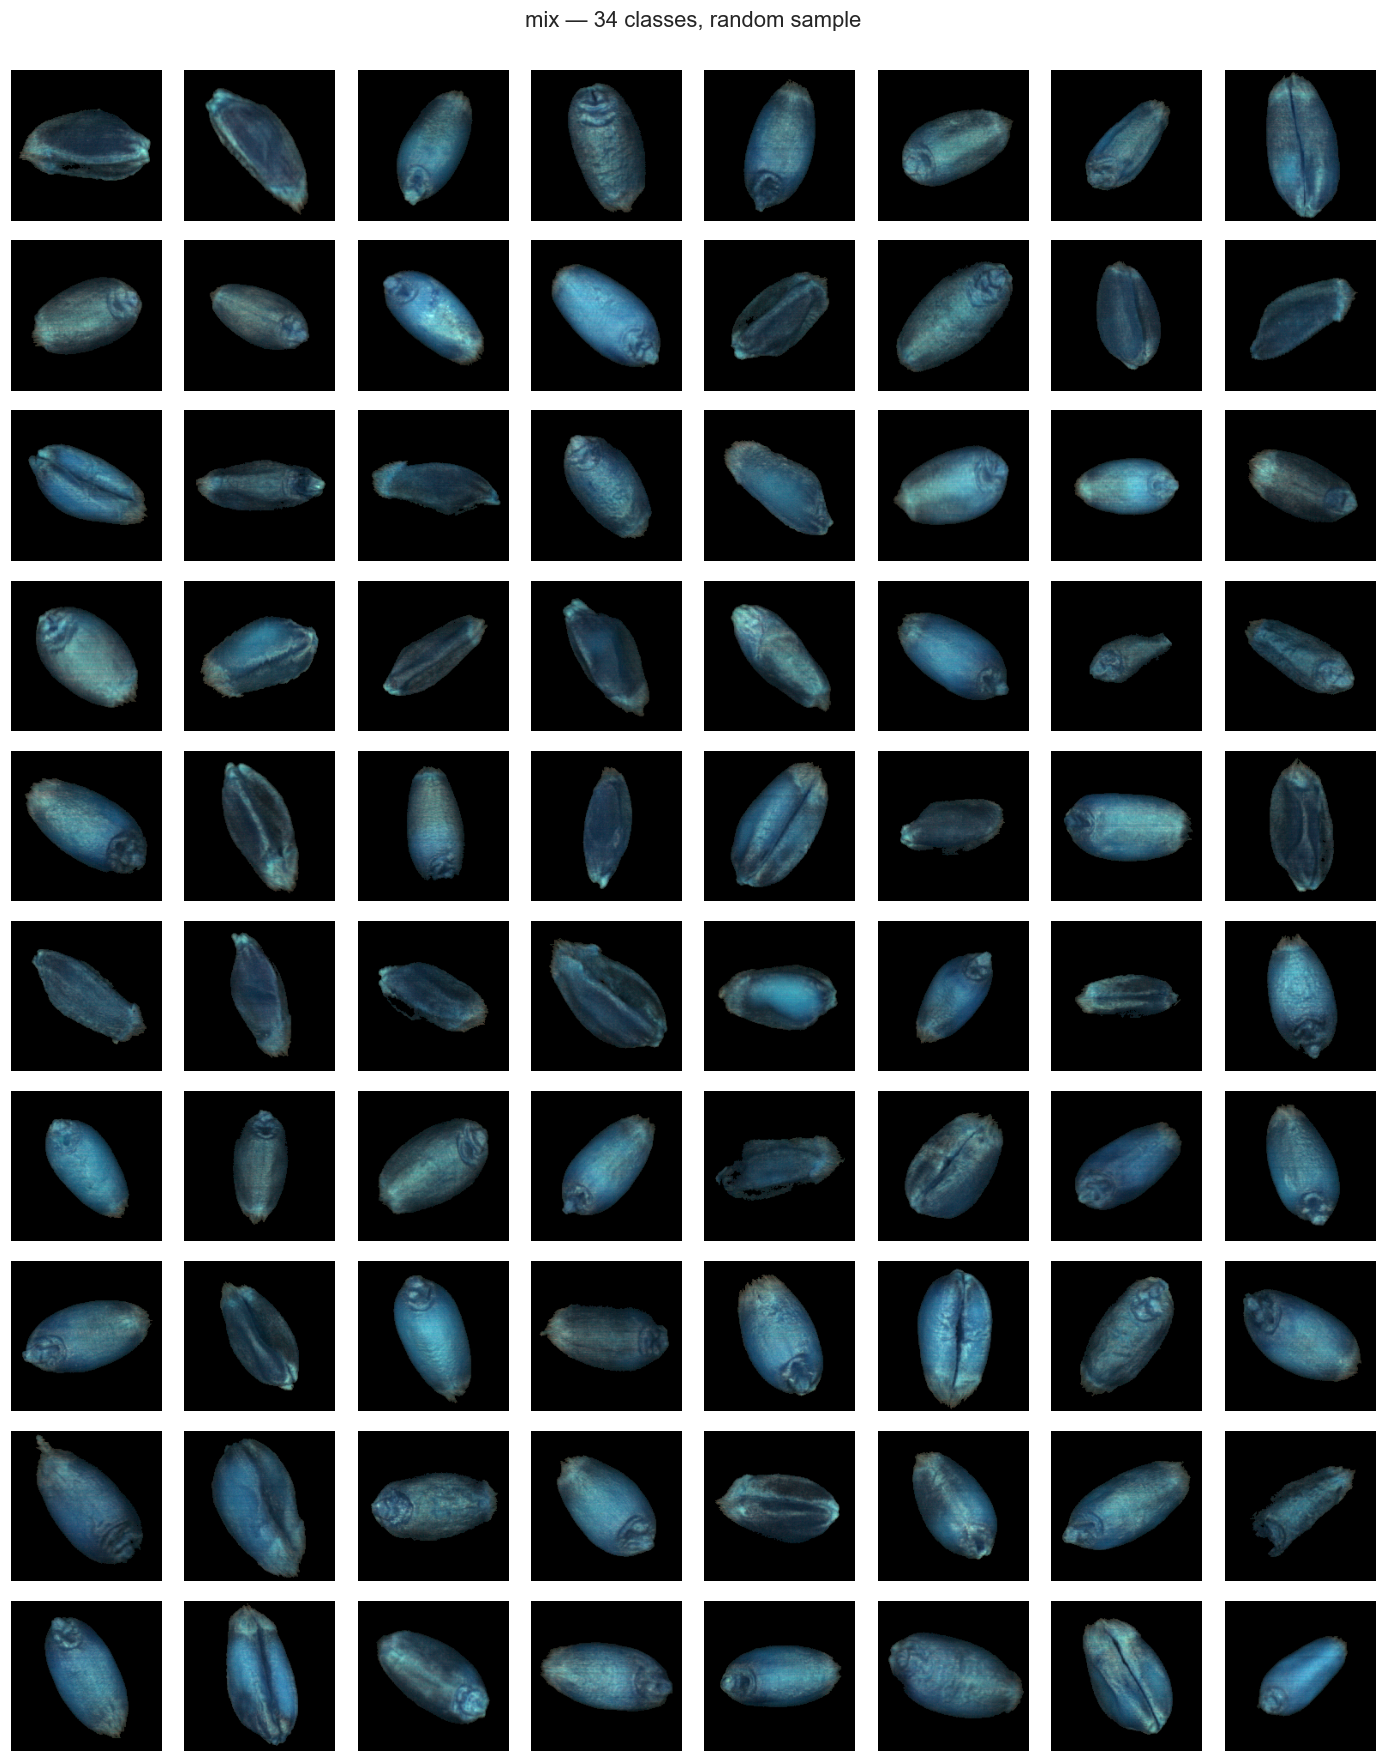

In [15]:
montage("bac")
montage("mix")

## 10. Findings

* **32,768 grains / 4 folders.** Pure perfomix (8 varieties, ~1.5× imbalance) and
  SCOOP (4 varieties across 11 bacs, ~1.5×) are near-balanced; the **34 observed
  mixtures are highly imbalanced (~14×)** — worth weighting or capping.
* **Splits are microplot-bound.** Most classes have exactly 2 microplots; BERGAMO
  has a 3rd (`x39y20`, the withdrawn plot) — the origin of the `c != 4`
  special-case in the split code. SCOOP is missing `bac14`.
* **Morphology is consistent** across classes (median area ≈ 8.5k px); a small
  low-area tail (near-empty `(0,0)` crops) are dust / half-grain artefacts →
  README §5.5 cleaning, easily filtered by the 2nd-percentile area cutoff shown.
* **Bands 53 & 89 are tightly correlated;** band 22 (blue) is the lowest-reflectance
  and most discriminative-looking channel. Class clouds overlap heavily in raw
  band means — the CNN's spatial/textural features are doing the real work.
* **Spectralon references** are stable within each campaign; watch for cross-dataset
  offsets when combining years.